# 🚂 Sysslan IT Solutions — Internship Project
## Level 2: Data Cleaning & Feature Engineering
**Project:** Train Route Analysis and Journey Time Prediction  
**Level:** 2 — Data Cleaning & Feature Engineering  
**Dataset:** Indian Railways Train Schedule  
---

## 📦 Step 0: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Load Dataset

In [3]:
df = pd.read_csv('Dataset1.csv')
print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 186,074 rows × 12 columns


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


---
## 🧹 Task 2.1 — Handle Missing Values & Remove Duplicates

In [4]:
print('🔍 BEFORE CLEANING')
print('=' * 45)
print(f'Total Rows       : {len(df):,}')
print(f'Duplicate Rows   : {df.duplicated().sum()}')
print(f'Missing Values   : {df.isnull().sum().sum()}')
print()
print('Missing per column:')
print(df.isnull().sum())

🔍 BEFORE CLEANING
Total Rows       : 186,074
Duplicate Rows   : 0
Missing Values   : 0

Missing per column:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [5]:
# Step 1: Remove duplicate rows
df_clean = df.drop_duplicates()
print(f'Rows after removing duplicates: {len(df_clean):,}')

# Step 2: Drop rows where critical columns are null
critical_cols = ['Train_No', 'Station_Code', 'Arrival_time', 'Departure_Time', 'Distance']
df_clean = df_clean.dropna(subset=critical_cols)
print(f'Rows after dropping null critical cols: {len(df_clean):,}')

# Step 3: Strip whitespace from string columns
df_clean['Station_Name'] = df_clean['Station_Name'].str.strip()
df_clean['Station_Code'] = df_clean['Station_Code'].str.strip()
df_clean['Arrival_time'] = df_clean['Arrival_time'].str.strip()
df_clean['Departure_Time'] = df_clean['Departure_Time'].str.strip()

print()
print('✅ AFTER CLEANING')
print('=' * 45)
print(f'Total Rows       : {len(df_clean):,}')
print(f'Duplicate Rows   : {df_clean.duplicated().sum()}')
print(f'Missing Values   : {df_clean.isnull().sum().sum()}')

Rows after removing duplicates: 186,074
Rows after dropping null critical cols: 186,074

✅ AFTER CLEANING
Total Rows       : 186,074
Duplicate Rows   : 0
Missing Values   : 0


---
## 🕐 Task 2.2 — Standardize Arrival & Departure Time Formats

In [6]:
# Check current time format
print('Current time format samples:')
print(df_clean[['Arrival_time', 'Departure_Time']].head(10).to_string())

Current time format samples:
  Arrival_time Departure_Time
0     00:00:00       10:25:00
1     11:06:00       11:08:00
2     11:28:00       11:30:00
3     12:10:00       00:00:00
4     00:00:00       20:30:00
5     21:04:00       21:06:00
6     21:26:00       21:28:00
7     22:25:00       00:00:00
8     19:40:00       19:40:00
9     20:18:00       20:20:00


In [7]:
def parse_time_to_minutes(time_str):
    """
    Converts HH:MM:SS string to total minutes since midnight.
    Returns None for invalid formats.
    """
    try:
        parts = str(time_str).strip().split(':')
        h = int(parts[0])
        m = int(parts[1])
        s = int(parts[2]) if len(parts) > 2 else 0
        return h * 60 + m + s / 60
    except:
        return None

# Convert times to minutes since midnight
df_clean = df_clean.copy()
df_clean['Arrival_Minutes']   = df_clean['Arrival_time'].apply(parse_time_to_minutes)
df_clean['Departure_Minutes'] = df_clean['Departure_Time'].apply(parse_time_to_minutes)

# Also keep a proper datetime-compatible column (using a dummy date)
df_clean['Arrival_Formatted']   = pd.to_datetime(df_clean['Arrival_time'],   format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M')
df_clean['Departure_Formatted'] = pd.to_datetime(df_clean['Departure_Time'], format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M')

print('✅ Time columns converted to minutes + formatted HH:MM')
print()
df_clean[['Station_Name', 'Arrival_time', 'Arrival_Formatted', 'Arrival_Minutes',
          'Departure_Time', 'Departure_Formatted', 'Departure_Minutes']].head(8)

✅ Time columns converted to minutes + formatted HH:MM



,Station_Name,Arrival_time,Arrival_Formatted,Arrival_Minutes,Departure_Time,Departure_Formatted,Departure_Minutes
0,SAWANTWADI R,00:00:00,00:00,0.0,10:25:00,10:25,625.0
1,THIVIM,11:06:00,11:06,666.0,11:08:00,11:08,668.0
2,KARMALI,11:28:00,11:28,688.0,11:30:00,11:30,690.0
3,MADGOAN JN.,12:10:00,12:10,730.0,00:00:00,00:00,0.0
4,MADGOAN JN.,00:00:00,00:00,0.0,20:30:00,20:30,1230.0
5,KARMALI,21:04:00,21:04,1264.0,21:06:00,21:06,1266.0
6,THIVIM,21:26:00,21:26,1286.0,21:28:00,21:28,1288.0
7,SAWANTWADI R,22:25:00,22:25,1345.0,00:00:00,00:00,0.0


---
## ⏱️ Task 2.3 — Calculate Total Journey Duration for Each Train

In [8]:
def calculate_journey_duration(train_group):
    """
    For each train:
    - Source station: Departure_Time of first stop
    - Destination station: Arrival_Time of last stop
    - Handles midnight crossover (e.g. train departs 22:00, arrives 06:00 next day)
    """
    train_group = train_group.sort_values('SN')
    
    first_row = train_group.iloc[0]
    last_row  = train_group.iloc[-1]
    
    dep_min = first_row['Departure_Minutes']
    arr_min = last_row['Arrival_Minutes']
    
    if pd.isna(dep_min) or pd.isna(arr_min):
        return None
    
    # Calculate duration
    duration = arr_min - dep_min
    
    # Handle midnight crossover
    if duration < 0:
        duration += 24 * 60  # Add 24 hours in minutes
    
    return round(duration, 2)

# Apply per train
journey_duration = df_clean.groupby('Train_No').apply(calculate_journey_duration).reset_index()
journey_duration.columns = ['Train_No', 'Journey_Duration_Min']

# Remove trains with None duration
journey_duration = journey_duration.dropna(subset=['Journey_Duration_Min'])

# Also add duration in hours
journey_duration['Journey_Duration_Hrs'] = (journey_duration['Journey_Duration_Min'] / 60).round(2)

print(f'✅ Journey duration calculated for {len(journey_duration):,} trains')
print()
print('Sample journey durations:')
journey_duration.head(10)

✅ Journey duration calculated for 11,113 trains

Sample journey durations:


C:\Users\spr49\AppData\Local\Temp\ipykernel_10536\1717285410.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  journey_duration = df_clean.groupby('Train_No').apply(calculate_journey_duration).reset_index()


,Train_No,Journey_Duration_Min,Journey_Duration_Hrs
0,107,105.0,1.75
1,108,115.0,1.92
2,128,1325.0,22.08
3,290,480.0,8.00
4,401,750.0,12.50
5,421,540.0,9.00
6,422,165.0,2.75
7,477,190.0,3.17
8,502,1380.0,23.00
9,504,60.0,1.00


In [ ]:
# Sanity check — remove unrealistic durations
# Min: at least 5 minutes | Max: 100 hours (very long multi-day trains)
before = len(journey_duration)
journey_duration = journey_duration[
    (journey_duration['Journey_Duration_Min'] >= 5) &
    (journey_duration['Journey_Duration_Hrs'] <= 100)
]
after = len(journey_duration)
print(f'Removed {before - after} unrealistic duration records')
print(f'Valid trains remaining: {after:,}')
print()
print('Journey Duration Statistics:')
print(journey_duration[['Journey_Duration_Min', 'Journey_Duration_Hrs']].describe().round(2))

---
## 🛠️ Task 2.4 — Create Features: Total Distance & Number of Stops

In [9]:
# Feature 1: Total Distance per train (max Distance value = last station cumulative distance)
total_distance = df_clean.groupby('Train_No')['Distance'].max().reset_index()
total_distance.columns = ['Train_No', 'Total_Distance_km']

# Feature 2: Number of Stops per train
num_stops = df_clean.groupby('Train_No')['Station_Code'].count().reset_index()
num_stops.columns = ['Train_No', 'Num_Stops']

# Feature 3: Start & End station info
route_info = df_clean.sort_values('SN').groupby('Train_No').agg(
    Source_Station=('Station_Name', 'first'),
    Source_Code=('Station_Code', 'first'),
    Destination_Station=('Station_Name', 'last'),
    Destination_Code=('Station_Code', 'last'),
    Departure_Time_Source=('Departure_Formatted', 'first'),
    Arrival_Time_Dest=('Arrival_Formatted', 'last')
).reset_index()

print('✅ Features created!')
print(f'   Total Distance : {len(total_distance)} trains')
print(f'   Num Stops      : {len(num_stops)} trains')
print(f'   Route Info     : {len(route_info)} trains')

✅ Features created!
   Total Distance : 11113 trains
   Num Stops      : 11113 trains
   Route Info     : 11113 trains


In [10]:
# Merge all features into one master dataframe
train_master = journey_duration \
    .merge(total_distance, on='Train_No', how='inner') \
    .merge(num_stops,      on='Train_No', how='inner') \
    .merge(route_info,     on='Train_No', how='inner')

print(f'✅ Master DataFrame created: {train_master.shape[0]:,} trains × {train_master.shape[1]} features')
print()
train_master.head(10)

✅ Master DataFrame created: 11,113 trains × 11 features



,Train_No,Journey_Duration_Min,Journey_Duration_Hrs,Total_Distance_km,Num_Stops,Source_Station,Source_Code,Destination_Station,Destination_Code,Departure_Time_Source,Arrival_Time_Dest
0,107,105.0,1.75,78,4,SAWANTWADI R,SWV,MADGOAN JN.,MAO,10:25,12:10
1,108,115.0,1.92,83,4,MADGOAN JN.,MAO,SAWANTWADI R,SWV,20:30,22:25
2,128,1325.0,22.08,978,22,MADGOAN JN.,MAO,CHHATRAPATI,KOP,19:40,17:45
3,290,480.0,8.00,2694,14,DELHI-SAFDAR,DSJ,DELHI-SAFDAR,DSJ,18:30,02:30
4,401,750.0,12.50,1618,12,AURANGABAD,AWB,VARANASI JN.,BSB,21:30,10:00
5,421,540.0,9.00,1276,5,LUCKNOW JN.,LKO,SHRI MATA VA,SVDK,23:00,08:00
6,422,165.0,2.75,1277,5,SHRI MATA VA,SVDK,LUCKNOW JN.,LKO,11:45,14:30
7,477,190.0,3.17,2616,14,SIRSA,SSA,SIRSA,SSA,12:10,15:20
8,502,1380.0,23.00,1206,9,RAJENDRANAGA,RJPB,AMBALA CANTT,UMB,10:30,09:30
9,504,60.0,1.00,1313,3,PATNA JN.,PNBE,BATHINDA JN,BTI,09:00,10:00


In [11]:
# Feature Engineering — Speed (avg km/h)
train_master['Avg_Speed_kmh'] = (
    train_master['Total_Distance_km'] / train_master['Journey_Duration_Hrs']
).round(2)

# Remove physically impossible speeds (>250 km/h = no Indian train goes that fast)
before = len(train_master)
train_master = train_master[
    (train_master['Avg_Speed_kmh'] > 0) &
    (train_master['Avg_Speed_kmh'] <= 250)
]
print(f'Removed {before - len(train_master)} trains with impossible speed values')
print(f'Final clean master DataFrame: {len(train_master):,} trains')
print()
print('Final feature summary:')
train_master[['Total_Distance_km', 'Num_Stops', 'Journey_Duration_Min', 
              'Journey_Duration_Hrs', 'Avg_Speed_kmh']].describe().round(2)

Removed 488 trains with impossible speed values
Final clean master DataFrame: 10,625 trains

Final feature summary:


,Total_Distance_km,Num_Stops,Journey_Duration_Min,Journey_Duration_Hrs,Avg_Speed_kmh
count,10625.00,10625.00,10625.00,10625.00,10625.00
mean,280.02,16.19,278.43,4.64,44.79
std,493.39,12.54,326.80,5.45,31.10
min,1.00,2.00,5.00,0.08,0.55
25%,37.00,7.00,60.00,1.00,31.52
50%,77.00,14.00,127.00,2.12,37.50
75%,242.00,22.00,370.00,6.17,45.19
max,3663.00,118.00,1435.00,23.92,249.74


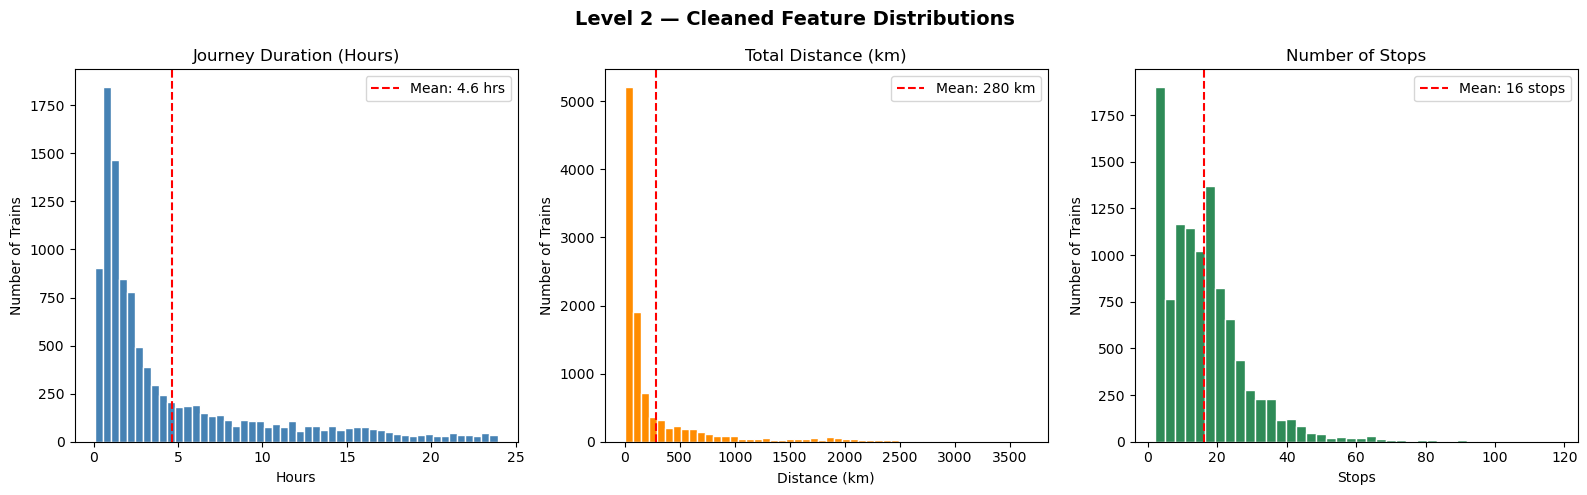

✅ Chart saved!


In [12]:
# Quick visualization — cleaned features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Level 2 — Cleaned Feature Distributions', fontsize=14, fontweight='bold')

# Journey Duration
axes[0].hist(train_master['Journey_Duration_Hrs'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Journey Duration (Hours)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Number of Trains')
axes[0].axvline(train_master['Journey_Duration_Hrs'].mean(), color='red',
                linestyle='--', label=f"Mean: {train_master['Journey_Duration_Hrs'].mean():.1f} hrs")
axes[0].legend()

# Total Distance
axes[1].hist(train_master['Total_Distance_km'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Total Distance (km)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Number of Trains')
axes[1].axvline(train_master['Total_Distance_km'].mean(), color='red',
                linestyle='--', label=f"Mean: {train_master['Total_Distance_km'].mean():.0f} km")
axes[1].legend()

# Number of Stops
axes[2].hist(train_master['Num_Stops'], bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Number of Stops')
axes[2].set_xlabel('Stops')
axes[2].set_ylabel('Number of Trains')
axes[2].axvline(train_master['Num_Stops'].mean(), color='red',
                linestyle='--', label=f"Mean: {train_master['Num_Stops'].mean():.0f} stops")
axes[2].legend()

plt.tight_layout()
plt.savefig('Level2_Feature_Distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

In [13]:
# Save cleaned master dataframe — will be used in Level 3, 4, 5, 6
train_master.to_csv('train_master_cleaned.csv', index=False)
df_clean.to_csv('dataset_cleaned.csv', index=False)

print('✅ Files saved:')
print('   → train_master_cleaned.csv  (per-train features, use this in Level 3+)')
print('   → dataset_cleaned.csv       (full cleaned row-level data)')

✅ Files saved:
   → train_master_cleaned.csv  (per-train features, use this in Level 3+)
   → dataset_cleaned.csv       (full cleaned row-level data)


In [14]:
# Final summary
print('=' * 60)
print('     ✅ LEVEL 2 SUMMARY — DATA CLEANING & FEATURES')
print('=' * 60)
print(f'  Duplicates Removed        : {df.duplicated().sum()}')
print(f'  Whitespace Cleaned        : ✅ Yes')
print(f'  Time Format Standardized  : HH:MM:SS → Minutes + HH:MM')
print(f'  Midnight Crossover Fixed  : ✅ Yes (added 24×60 min)')
print(f'  Journey Duration Created  : ✅ In Minutes & Hours')
print(f'  Total Distance Feature    : ✅ km per train')
print(f'  Num Stops Feature         : ✅ stops per train')
print(f'  Avg Speed Feature         : ✅ km/h per train')
print(f'  Impossible Speeds Removed : ✅ Speed > 250 km/h dropped')
print(f'  Final Clean Trains        : {len(train_master):,}')
print(f'  Avg Journey Duration      : {train_master["Journey_Duration_Hrs"].mean():.2f} hrs')
print(f'  Avg Distance              : {train_master["Total_Distance_km"].mean():.2f} km')
print(f'  Avg Stops                 : {train_master["Num_Stops"].mean():.2f}')
print('=' * 60)
print('  ✅ Ready for Level 3 — Data Exploration!')
print('=' * 60)

     ✅ LEVEL 2 SUMMARY — DATA CLEANING & FEATURES
  Duplicates Removed        : 0
  Whitespace Cleaned        : ✅ Yes
  Time Format Standardized  : HH:MM:SS → Minutes + HH:MM
  Midnight Crossover Fixed  : ✅ Yes (added 24×60 min)
  Journey Duration Created  : ✅ In Minutes & Hours
  Total Distance Feature    : ✅ km per train
  Num Stops Feature         : ✅ stops per train
  Avg Speed Feature         : ✅ km/h per train
  Impossible Speeds Removed : ✅ Speed > 250 km/h dropped
  Final Clean Trains        : 10,625
  Avg Journey Duration      : 4.64 hrs
  Avg Distance              : 280.02 km
  Avg Stops                 : 16.19
  ✅ Ready for Level 3 — Data Exploration!
